# Results from `src/artifacts`

A quick notebook to compare the saved test results for the image, text, and multimodal models.

In [6]:
from collections import Counter
from pathlib import Path
import csv
import json

from IPython.display import Image, Markdown, display

ROOT = Path("src/artifacts") if Path("src/artifacts").exists() else Path("artifacts")
SECTIONS = {
    "Image": "best_image",
    "Text": "best_text",
    "Multimodal": "best_multimodal",
}


def load_result(folder):
    test_dir = ROOT / folder / "test"
    with open(test_dir / "metrics.json") as f:
        metrics = json.load(f)
    with open(test_dir / "misclassified.csv", newline="") as f:
        errors = list(csv.DictReader(f))
    for row in errors:
        row["confidence"] = float(row["confidence"] or 0)
        row["file"] = Path(row["path"]).name
    return test_dir, metrics, errors


def md_table(rows, columns):
    def fmt(value):
        if isinstance(value, float):
            value = f"{value:.3f}"
        return str(value).replace("|", "\\|")

    lines = [
        "| " + " | ".join(columns) + " |",
        "| " + " | ".join(["---"] * len(columns)) + " |",
    ]
    for row in rows:
        lines.append("| " + " | ".join(fmt(row[col]) for col in columns) + " |")
    return "\n".join(lines)


RESULTS = {name: load_result(folder) for name, folder in SECTIONS.items()}


def show_model(name):
    test_dir, metrics, errors = RESULTS[name]

    summary = [{
        "accuracy": metrics["acc"],
        "macro_f1": metrics["macro_f1"],
        "macro_roc_auc": metrics["macro_roc_auc"],
        "loss": metrics["loss"],
        "errors": int(metrics["misclassified_total"]),
    }]
    display(Markdown("### Summary\n\n" + md_table(summary, ["accuracy", "macro_f1", "macro_roc_auc", "loss", "errors"])))

    class_rows = []
    for label in metrics["class_names"]:
        stats = metrics["per_class"][label]
        class_rows.append({
            "label": label,
            "precision": stats["precision"],
            "recall": stats["recall"],
            "f1": stats["f1"],
        })
    display(Markdown("### Per-class scores\n\n" + md_table(class_rows, ["label", "precision", "recall", "f1"])))

    display(Markdown("### Confusion matrix"))
    display(Image(filename=str(test_dir / "confusion_matrix.png")))
    display(Markdown("### ROC curves"))
    display(Image(filename=str(test_dir / "roc_curves.png")))

    common = Counter((row["true_label"], row["pred_label"]) for row in errors).most_common(5)
    common_rows = [{"true": t, "pred": p, "count": c} for (t, p), c in common]
    display(Markdown("### Common mistakes\n\n" + md_table(common_rows, ["true", "pred", "count"])))

    top_errors = sorted(errors, key=lambda row: row["confidence"], reverse=True)[:5]
    sample_rows = [{
        "file": row["file"],
        "true": row["true_label"],
        "pred": row["pred_label"],
        "confidence": row["confidence"],
        "text": row["raw_text"],
    } for row in top_errors]
    display(Markdown("### Highest-confidence mistakes\n\n" + md_table(sample_rows, ["file", "true", "pred", "confidence", "text"])))

## Overall comparison

In [7]:
summary_rows = []
for name, (_, metrics, _) in RESULTS.items():
    summary_rows.append({
        "model": name,
        "accuracy": metrics["acc"],
        "macro_f1": metrics["macro_f1"],
        "macro_roc_auc": metrics["macro_roc_auc"],
        "loss": metrics["loss"],
        "errors": int(metrics["misclassified_total"]),
    })

display(Markdown(md_table(summary_rows, ["model", "accuracy", "macro_f1", "macro_roc_auc", "loss", "errors"])))

labels = RESULTS["Image"][1]["class_names"]
f1_rows = []
for label in labels:
    row = {"label": label}
    for name, (_, metrics, _) in RESULTS.items():
        row[name] = metrics["per_class"][label]["f1"]
    f1_rows.append(row)

display(Markdown("### Per-class F1\n\n" + md_table(f1_rows, ["label", "Image", "Text", "Multimodal"])))

| model | accuracy | macro_f1 | macro_roc_auc | loss | errors |
| --- | --- | --- | --- | --- | --- |
| Image | 0.738 | 0.727 | 0.918 | 0.667 | 899 |
| Text | 0.793 | 0.784 | 0.913 | 0.812 | 709 |
| Multimodal | 0.757 | 0.750 | 0.931 | 0.674 | 833 |

### Per-class F1

| label | Image | Text | Multimodal |
| --- | --- | --- | --- |
| Black | 0.565 | 0.692 | 0.646 |
| Blue | 0.748 | 0.818 | 0.778 |
| Green | 0.864 | 0.854 | 0.854 |
| TTR | 0.730 | 0.772 | 0.722 |

## Image

### Summary

| accuracy | macro_f1 | macro_roc_auc | loss | errors |
| --- | --- | --- | --- | --- |
| 0.738 | 0.727 | 0.918 | 0.667 | 899 |

### Per-class scores

| label | precision | recall | f1 |
| --- | --- | --- | --- |
| Black | 0.651 | 0.499 | 0.565 |
| Blue | 0.700 | 0.803 | 0.748 |
| Green | 0.860 | 0.869 | 0.864 |
| TTR | 0.732 | 0.728 | 0.730 |

### Confusion matrix

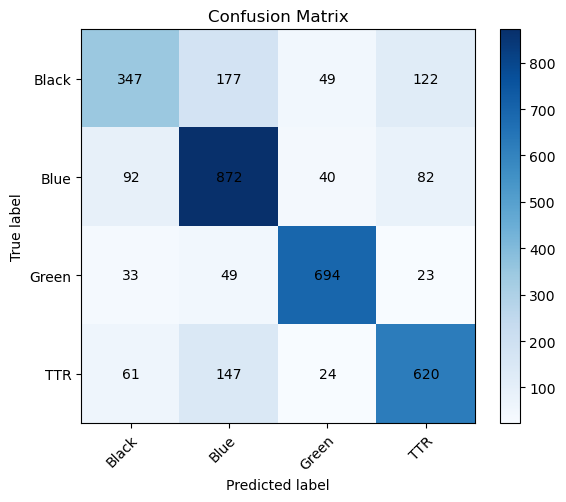

### ROC curves

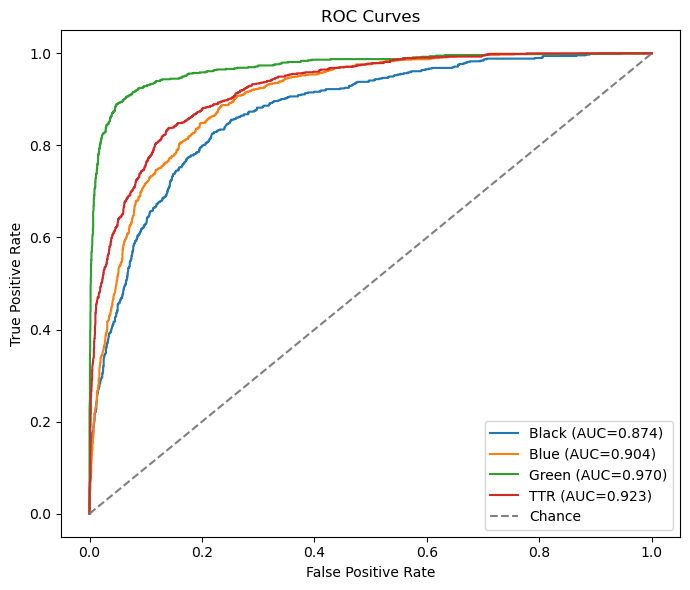

### Common mistakes

| true | pred | count |
| --- | --- | --- |
| Black | Blue | 177 |
| TTR | Blue | 147 |
| Black | TTR | 122 |
| Blue | Black | 92 |
| Blue | TTR | 82 |

### Highest-confidence mistakes

| file | true | pred | confidence | text |
| --- | --- | --- | --- | --- |
| sponge_1054.png | Black | Green | 0.996 |  |
| cardboard_box_coffee_pod_3057.png | Blue | TTR | 0.996 |  |
| waste_bubble_gum_792.png | Black | Green | 0.995 |  |
| Deoderant_Container_114.png | Black | TTR | 0.994 |  |
| phone_packaging_1544.png | Blue | TTR | 0.994 |  |

In [8]:
show_model("Image")

## Text

### Summary

| accuracy | macro_f1 | macro_roc_auc | loss | errors |
| --- | --- | --- | --- | --- |
| 0.793 | 0.784 | 0.913 | 0.812 | 709 |

### Per-class scores

| label | precision | recall | f1 |
| --- | --- | --- | --- |
| Black | 0.768 | 0.630 | 0.692 |
| Blue | 0.758 | 0.888 | 0.818 |
| Green | 0.803 | 0.912 | 0.854 |
| TTR | 0.868 | 0.695 | 0.772 |

### Confusion matrix

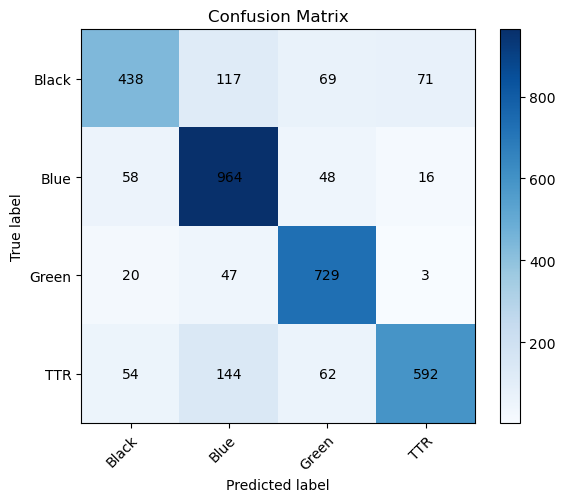

### ROC curves

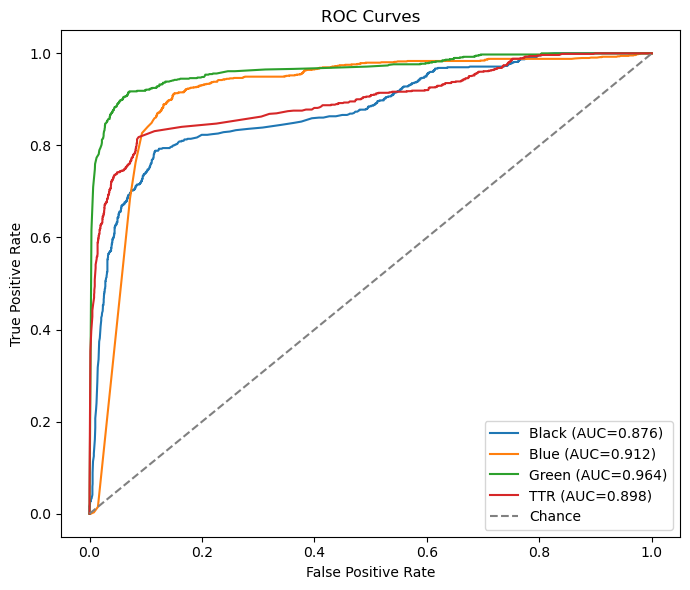

### Common mistakes

| true | pred | count |
| --- | --- | --- |
| TTR | Blue | 144 |
| Black | Blue | 117 |
| Black | TTR | 71 |
| Black | Green | 69 |
| TTR | Green | 62 |

### Highest-confidence mistakes

| file | true | pred | confidence | text |
| --- | --- | --- | --- | --- |
| expired_meat_183.png | Black | Green | 0.990 | expired meat 183 |
| expired_meat_694.png | Black | Green | 0.990 | expired meat 694 |
| Kiwi_Peel_2441.png | Blue | Green | 0.990 | kiwi peel 2441 |
| expired_fish_dinner_2969.png | Blue | Green | 0.990 | expired fish dinner 2969 |
| leftover_essential_oils_1436.png | Blue | Green | 0.990 | leftover essential oils 1436 |

In [9]:
show_model("Text")

## Multimodal

### Summary

| accuracy | macro_f1 | macro_roc_auc | loss | errors |
| --- | --- | --- | --- | --- |
| 0.757 | 0.750 | 0.931 | 0.674 | 833 |

### Per-class scores

| label | precision | recall | f1 |
| --- | --- | --- | --- |
| Black | 0.616 | 0.678 | 0.646 |
| Blue | 0.760 | 0.797 | 0.778 |
| Green | 0.792 | 0.926 | 0.854 |
| TTR | 0.878 | 0.614 | 0.722 |

### Confusion matrix

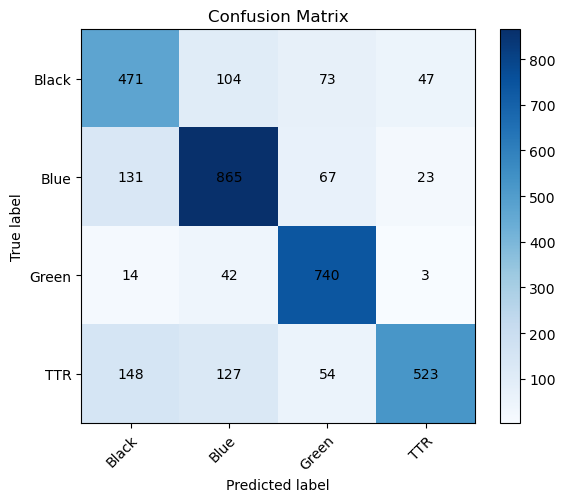

### ROC curves

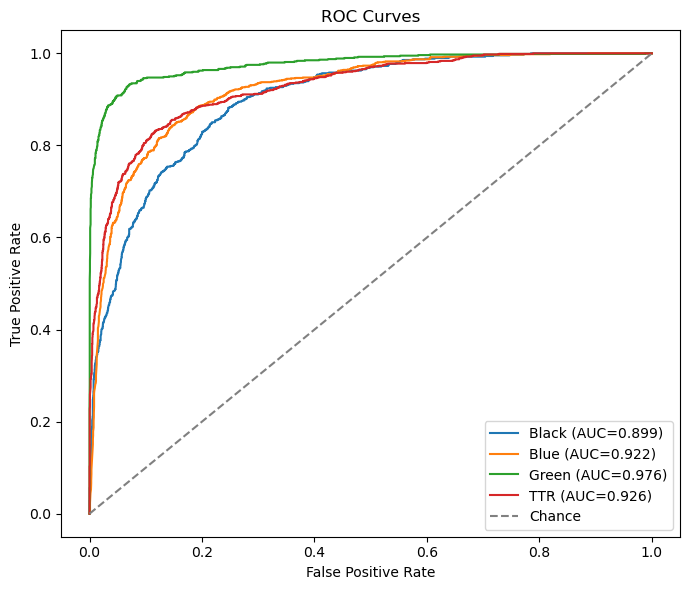

### Common mistakes

| true | pred | count |
| --- | --- | --- |
| TTR | Black | 148 |
| Blue | Black | 131 |
| TTR | Blue | 127 |
| Black | Blue | 104 |
| Black | Green | 73 |

### Highest-confidence mistakes

| file | true | pred | confidence | text |
| --- | --- | --- | --- | --- |
| unused_paper_towel_3275.png | Blue | Green | 0.998 | unused paper towel 3275 |
| dirty_carboard_pizza_box_12.png | Green | Blue | 0.998 | dirty carboard pizza box 12 |
| syrup_3386.png | Black | Blue | 0.996 | syrup 3386 |
| CD_case_2519.png | TTR | Blue | 0.994 | cd case 2519 |
| paper_straw_1861.png | Blue | Green | 0.993 | paper straw 1861 |

In [10]:
show_model("Multimodal")